In [2]:
import jax 
import jax.numpy as jnp
from jax.scipy.stats import gamma
from jax import random

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%load_ext autoreload
%autoreload 2

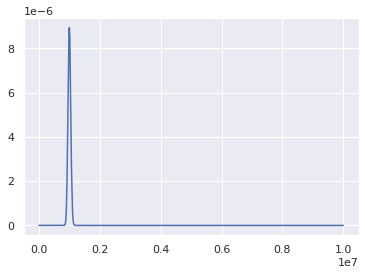

In [3]:
# What does the prior look like?
n_samples = 1000
s_target = 1e-6

alpha = n_samples / 2
beta = n_samples / 2 * s_target

x = jnp.linspace(0, 10 * 1 / s_target, 1e6)
plt.plot(x, gamma.pdf(x, a=alpha, scale=1/beta), '-') # scipy uses k/theta parametrization instead of alpha/beta

(1e-07, 0.001)

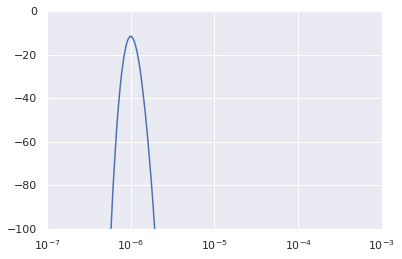

In [4]:
# Now plot it in terms of variance and log
plt.plot(1 / x, gamma.logpdf(x, a=alpha, scale=1/beta), '-')
plt.xscale('log')
plt.ylim([-100, 0])
plt.xlim([s_target / 10, 1e-3])

In [5]:
from jax import jit, numpy as jnp, random

from modax.training.convergence import Convergence
from modax.training.sparsity_scheduler import mask_scheduler
from modax.training.logging import Logger
from flax.core import freeze
from modax.training import train_probabilistic_mse
from modax.training.utils import create_stateful_update
from sklearn.model_selection import train_test_split
from modax.training.utils import validation_metric
from modax.losses.bayesian import loss_fn_mse_precalc

In [6]:
# Custom train function which always runs until max_its

def train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn,
    val_fn,
    mask_update_fn,
    X,
    y,
    max_epochs=1e4,
    split=0.2,
    rand_seed=42,
    **loss_fn_kwargs,
):
    # Making test / train
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=rand_seed
    )

    # Creating update functions
    update = create_stateful_update(
        loss_fn, model=model, x=X_train, y=y_train, **loss_fn_kwargs
    )

    logger = Logger()
    scheduler = mask_scheduler(delta=0.0, patience=10000)
    converged = Convergence()

    for epoch in jnp.arange(max_epochs):
        (optimizer, state), train_metrics, output = update(optimizer, state)
        prediction, dt, theta, coeffs = output

        if epoch % 1000 == 0:
            print(f"Loss step {epoch}: {train_metrics['loss']}")

        if epoch % 500 == 0:
            val_metrics = val_fn(
                optimizer,
                state,
                X_test,
                y_test,
                (train_metrics["tau"], train_metrics["nu"]),
            )
            metrics = {**train_metrics, **val_metrics}
            logger.write(metrics, epoch)

            apply_sparsity, optimizer = scheduler(
                metrics["mse"], epoch, optimizer
            )  # we need to find the minimum neg LL of the mse

            if apply_sparsity:
                mask = mask_update_fn(theta, dt)
                state = freeze({"vars": {"MaskedLeastSquares_0": {"mask": mask}}})

        #if converged(epoch, coeffs):
        #    mask = mask_update_fn(theta, dt)
        #    print(f"Converged at epoch {epoch} with mask {mask[:, None]}.")
        #    break

    logger.close()
    return optimizer, state

In [7]:
from jax import numpy as jnp
from jax.scipy.special import erfc


def DoubleSoliton(x, t, c, x0):
    """[summary]
    source: http://lie.math.brocku.ca/~sanco/solitons/kdv_solitons.php
    Args:
        x ([type]): [description]
        t ([type]): [description]
        c ([type]): [description]
        x0 ([type]): [description]
    """
    assert c[0] > c[1], 'c1 has to be bigger than c[2]'
    
    xi0 = jnp.sqrt(c[0]) / 2 * (x - c[0] * t - x0[0]) # switch to moving coordinate frame
    xi1 = jnp.sqrt(c[1]) / 2 * (x - c[1] * t - x0[1])

    part_1 = 2 * (c[0] - c[1])
    numerator = c[0] * jnp.cosh(xi1)**2 + c[1] * jnp.sinh(xi0)**2
    denominator_1 = (jnp.sqrt(c[0]) - jnp.sqrt(c[1])) * jnp.cosh(xi0 + xi1)
    denominator_2 = (jnp.sqrt(c[0]) + jnp.sqrt(c[1])) * jnp.cosh(xi0 - xi1)
    u = part_1 * numerator / (denominator_1 + denominator_2)**2
    return u

In [8]:
# %% Imports
from modax.data.burgers import burgers
from modax.models import DeepmodBayes
from modax.linear_model.mask_estimator import ThresholdedLasso
from modax.losses.bayesian import loss_fn_pinn_bayes_typeII
from flax import optim

In [9]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 50)
t = jnp.linspace(0.1, 1.0, 20)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.1 * jnp.std(y) * random.normal(key, y.shape)

In [10]:
jnp.linalg.norm(jnp.gradient(u, t[1]-t[0], axis=0))

DeviceArray(93.47293, dtype=float32)

In [11]:
jnp.max(u)

DeviceArray(2.499827, dtype=float32)

In [12]:
 (0.1 * jnp.std(y))**2

DeviceArray(0.00335406, dtype=float32)

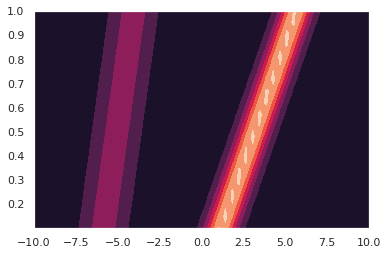

In [13]:
plt.contourf(x_grid, t_grid, u)

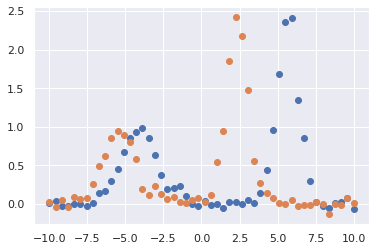

In [14]:
frame = 40
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'o')

frame = 5
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'o')

In [15]:
val_fn = jit(lambda opt, state, X, y, args: validation_metric(params=opt.target, state=state, model=model, x=X, y=y, prior_params_mse=prior_params_mse, prior_params_reg=prior_params_reg, train_params=args))

In [16]:
# Setting priors
n_samples = X.shape[0]
prior_params_reg = (n_samples/2, n_samples/2 * 1e-4)
prior_params_mse = (0.0, 0.0)

In [17]:
model = DeepmodBayes([30, 30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

mask_fn = ThresholdedLasso(threshold=0.1)

In [18]:
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_mse_precalc,
    val_fn,
    X,
    y,
    max_epochs=50000,
    split=0.8,
    rand_seed=42,
)

Loss step 0: 198.7111358642578
Loss step 1000: -303.9903869628906


In [22]:
params = optimizer.target
optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
optimizer = optimizer.create(params)

In [26]:
optimizer, state = train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn_pinn_bayes_typeII,
    val_fn,
    mask_fn,
    X,
    y,
    max_epochs=10000,
    split=0.8,
    rand_seed=42,
    prior_params_reg = prior_params_reg,
    prior_params_mse = prior_params_mse
)

Loss step 0: -1543.5135498046875
Loss step 1000: -4587.5048828125
Loss step 2000: -4652.12744140625
Loss step 3000: -4538.1162109375
Loss step 4000: -4695.00048828125
Loss step 5000: -4680.63720703125
Loss step 6000: -4683.7763671875
Loss step 7000: -4686.65966796875
Loss step 8000: -4686.65966796875
Loss step 9000: -4686.66357421875


In [27]:
variables = {"params": optimizer.target, **state}
prediction = model.apply(variables, X, mutable=list(state.keys()))[0][0].reshape(x_grid.shape)

In [28]:
state

FrozenDict({
    vars: {
        MaskedLeastSquares_0: {
            mask: DeviceArray([ True,  True,  True,  True,  True,  True,  True,  True,
                          True,  True,  True,  True], dtype=bool),
        },
    },
})

In [47]:
prediction[8,:].shape

(50,)

In [48]:
jnp.linspace(-10, 10, 100).shape

(100,)

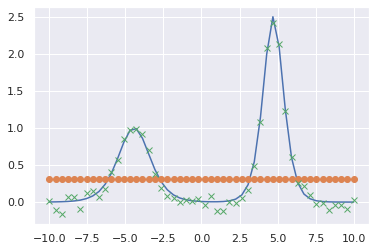

In [29]:
frame = 15
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [30]:
dt - coeff @ theta

NameError: name 'dt' is not defined